# 05. Submission

이 노트북은 `04_modeling.ipynb`에서 선택한 best modeling 후보를 전체 train 데이터에 재학습하고 Kaggle 제출 파일을 생성합니다.

사용 설정:

- feature set: `data/proceed/train_fe_v2.csv`, `data/proceed/test_fe_v2.csv`
- model: `v2_hgb_log_leaf45_clip`
- target transform: `log1p(Rings)` 학습 후 `expm1` 복원
- feature clipping: train 기준 quantile `0.5%`~`99.5%`
- output: `submissions/submission_v2_hgb_log_leaf45_clip.csv`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCEED_DIR = PROJECT_ROOT / "data" / "proceed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCEED_DIR / "train_fe_v2.csv"
TEST_PATH = PROCEED_DIR / "test_fe_v2.csv"
SAMPLE_SUBMISSION_PATH = RAW_DIR / "sample_submission.csv"
SUBMISSION_PATH = SUBMISSION_DIR / "submission_v2_hgb_log_leaf45_clip.csv"

ID_COL = "id"
TARGET = "Rings"

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.6f}".format)
sns.set_theme(style="whitegrid", context="notebook")


## 1. Load Inputs

Submission은 modeling에서 선택된 v2 feature dataset과 Kaggle sample submission 형식을 사용합니다.


In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
X = train[feature_cols]
y = train[TARGET]
X_test = test[feature_cols]

print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"sample_submission: {sample_submission.shape}")
print(f"features: {len(feature_cols)}")

display(train.head())
display(test.head())
display(sample_submission.head())


train: (90615, 41)
test : (60411, 40)
sample_submission: (60411, 2)
features: 39


,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Height_is_zero,Volume,Density,Shucked_ratio,Viscera_ratio,Shell_ratio,Shell_to_shucked,Sex_F,Sex_I,Sex_M,Area,Diameter_to_Length,Height_to_Length,Height_to_Diameter,Component_weight_sum,Component_sum_ratio,Residual_weight,Residual_weight_ratio,Whole_weight_to_Length,Whole_weight_to_Area,Whole_weight_to_Volume,Shucked_to_Shell,Viscera_to_Shell,log1p_Length,log1p_Diameter,log1p_Height,log1p_Whole_weight,log1p_Shucked_weight,log1p_Viscera_weight,log1p_Shell_weight,log1p_Volume,log1p_Density,Rings
0,0,0.550000,0.430000,0.150000,0.771500,0.328500,0.146500,0.240000,0,0.035475,21.747710,0.425794,0.189890,0.311082,0.730594,1,0,0,0.236500,0.781818,0.272727,0.348837,0.715000,0.926766,0.056500,0.073234,1.402727,3.262156,21.747710,1.368750,0.610417,0.438255,0.357674,0.139762,0.571827,0.284050,0.136714,0.215111,0.034860,3.124464,11
1,1,0.630000,0.490000,0.145000,1.130000,0.458000,0.276500,0.320000,0,0.044761,25.244909,0.405310,0.244690,0.283186,0.698690,1,0,0,0.308700,0.777778,0.230159,0.295918,1.054500,0.933186,0.075500,0.066814,1.793651,3.660512,25.244909,1.431250,0.864063,0.488580,0.398776,0.135405,0.756122,0.377066,0.244122,0.277632,0.043789,3.267472,11
2,2,0.160000,0.110000,0.025000,0.021000,0.005500,0.003000,0.005000,0,0.000440,47.727273,0.261905,0.142857,0.238095,0.909091,0,1,0,0.017600,0.687500,0.156250,0.227273,0.013500,0.642857,0.007500,0.357143,0.131250,1.193182,47.727273,1.100000,0.600000,0.148420,0.104360,0.024693,0.020783,0.005485,0.002996,0.004988,0.000440,3.886239,6
3,3,0.595000,0.475000,0.150000,0.914500,0.375500,0.205500,0.250000,0,0.042394,21.571576,0.410607,0.224713,0.273373,0.665779,0,0,1,0.282625,0.798319,0.252101,0.315789,0.831000,0.908693,0.083500,0.091307,1.536975,3.235736,21.571576,1.502000,0.822000,0.466874,0.388658,0.139762,0.649456,0.318817,0.186894,0.223144,0.041520,3.116691,10
4,4,0.555000,0.425000,0.130000,0.782000,0.369500,0.160000,0.197500,0,0.030664,25.502426,0.472506,0.204604,0.252558,0.534506,0,1,0,0.235875,0.765766,0.234234,0.305882,0.727000,0.929668,0.055000,0.070332,1.409009,3.315315,25.502426,1.870886,0.810127,0.441476,0.354172,0.122218,0.577736,0.314446,0.148420,0.180236,0.030203,3.277236,9


,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Height_is_zero,Volume,Density,Shucked_ratio,Viscera_ratio,Shell_ratio,Shell_to_shucked,Sex_F,Sex_I,Sex_M,Area,Diameter_to_Length,Height_to_Length,Height_to_Diameter,Component_weight_sum,Component_sum_ratio,Residual_weight,Residual_weight_ratio,Whole_weight_to_Length,Whole_weight_to_Area,Whole_weight_to_Volume,Shucked_to_Shell,Viscera_to_Shell,log1p_Length,log1p_Diameter,log1p_Height,log1p_Whole_weight,log1p_Shucked_weight,log1p_Viscera_weight,log1p_Shell_weight,log1p_Volume,log1p_Density
0,90615,0.645000,0.475000,0.155000,1.238000,0.618500,0.312500,0.300500,0,0.047488,26.069675,0.499596,0.252423,0.242730,0.485853,0,0,1,0.306375,0.736434,0.240310,0.326316,1.231500,0.994750,0.006500,0.005250,1.919380,4.040800,26.069675,2.058236,1.039933,0.497740,0.388658,0.144100,0.805583,0.481500,0.271934,0.262749,0.046395,3.298414
1,90616,0.580000,0.460000,0.160000,0.983000,0.478500,0.219500,0.275000,0,0.042688,23.027549,0.486775,0.223296,0.279756,0.574713,0,0,1,0.266800,0.793103,0.275862,0.347826,0.973000,0.989827,0.010000,0.010173,1.694828,3.684408,23.027549,1.740000,0.798182,0.457425,0.378436,0.148420,0.684611,0.391028,0.198441,0.242946,0.041802,3.179201
2,90617,0.560000,0.420000,0.140000,0.839500,0.352500,0.184500,0.240500,0,0.032928,25.495019,0.419893,0.219774,0.286480,0.682270,0,0,1,0.235200,0.750000,0.250000,0.333333,0.777500,0.926147,0.062000,0.073853,1.499107,3.569303,25.495019,1.465696,0.767152,0.444686,0.350657,0.131028,0.609494,0.301955,0.169321,0.215515,0.032397,3.276957
3,90618,0.570000,0.490000,0.145000,0.874000,0.352500,0.186500,0.235000,0,0.040498,21.581046,0.403318,0.213387,0.268879,0.666667,0,0,1,0.279300,0.859649,0.254386,0.295918,0.774000,0.885584,0.100000,0.114416,1.533333,3.129252,21.581046,1.500000,0.793617,0.451076,0.398776,0.135405,0.628075,0.301955,0.171008,0.211071,0.039700,3.117111
4,90619,0.415000,0.325000,0.110000,0.358000,0.157500,0.067000,0.105000,0,0.014836,24.130087,0.439944,0.187151,0.293296,0.666667,0,1,0,0.134875,0.783133,0.265060,0.338462,0.329500,0.920391,0.028500,0.079609,0.862651,2.654310,24.130087,1.500000,0.638095,0.347130,0.281412,0.104360,0.306013,0.146263,0.064851,0.099845,0.014727,3.224066


,id,Rings
0,90615,10
1,90616,10
2,90617,10
3,90618,10
4,90619,10


## 2. Validate Submission Inputs

제출 파일은 test id 순서와 sample submission 형식을 그대로 따라야 합니다.


In [3]:
def validate_submission_inputs(train_df: pd.DataFrame, test_df: pd.DataFrame, sample_df: pd.DataFrame, features: list[str]) -> None:
    assert ID_COL in train_df.columns and ID_COL in test_df.columns and ID_COL in sample_df.columns, "id column is required."
    assert TARGET in train_df.columns and TARGET in sample_df.columns, "Rings column is required in train/sample submission."
    assert TARGET not in test_df.columns, "test feature file must not contain target."
    assert train_df[ID_COL].is_unique and test_df[ID_COL].is_unique, "id values must be unique."
    assert test_df[ID_COL].equals(sample_df[ID_COL]), "test id order must match sample_submission id order."
    assert features == [c for c in test_df.columns if c != ID_COL], "train/test feature schema differs."
    assert train_df[features + [TARGET]].isna().sum().sum() == 0, "train has missing values."
    assert test_df[features].isna().sum().sum() == 0, "test has missing values."
    assert np.isfinite(train_df[features + [TARGET]].to_numpy()).all(), "train has non-finite values."
    assert np.isfinite(test_df[features].to_numpy()).all(), "test has non-finite values."
    assert (train_df[TARGET] >= 0).all(), "RMSLE target must be non-negative."

validate_submission_inputs(train, test, sample_submission, feature_cols)

validation_summary = pd.DataFrame(
    {
        "train": [len(train), train.shape[1], train[feature_cols].isna().sum().sum(), y.min(), y.mean(), y.max()],
        "test": [len(test), test.shape[1], test[feature_cols].isna().sum().sum(), np.nan, np.nan, np.nan],
    },
    index=["rows", "columns", "missing_feature_cells", "target_min", "target_mean", "target_max"],
)

display(validation_summary)


,train,test
rows,90615.000000,60411.000000
columns,41.000000,40.000000
missing_feature_cells,0.000000,0.000000
target_min,1.000000,NaN
target_mean,9.696794,NaN
target_max,29.000000,NaN


## 3. Recreate Final Model

`04_modeling.ipynb`의 best experiment인 `v2_hgb_log_leaf45_clip`을 재현합니다. Quantile clipping은 전체 train에 fit한 뒤 test에 적용됩니다.


In [4]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower: float = 0.005, upper: float = 0.995):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.columns_ = X_df.columns
        self.lower_bounds_ = X_df.quantile(self.lower)
        self.upper_bounds_ = X_df.quantile(self.upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=getattr(self, "columns_", None)).copy()
        return X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)


def make_final_model(random_state: int = RANDOM_STATE) -> TransformedTargetRegressor:
    base_model = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.035,
        max_iter=600,
        max_leaf_nodes=45,
        min_samples_leaf=30,
        l2_regularization=0.04,
        early_stopping=True,
        random_state=random_state,
    )
    pipeline = make_pipeline(QuantileClipper(0.005, 0.995), base_model)
    return TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

final_model = make_final_model()
final_model


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",False
,lower,0.005
,upper,0.995
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.035
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",600


## 4. Train Final Model and Predict Test

전체 train 데이터로 재학습하고 test 예측을 생성합니다. RMSLE 평가 특성상 음수 예측은 0으로 clipping합니다.


,predicted_Rings
count,60411.000000
mean,9.571239
std,2.503179
min,3.905400
1%,4.349329
5%,5.628000
50%,9.399550
95%,14.242099
99%,16.497288
max,19.401212


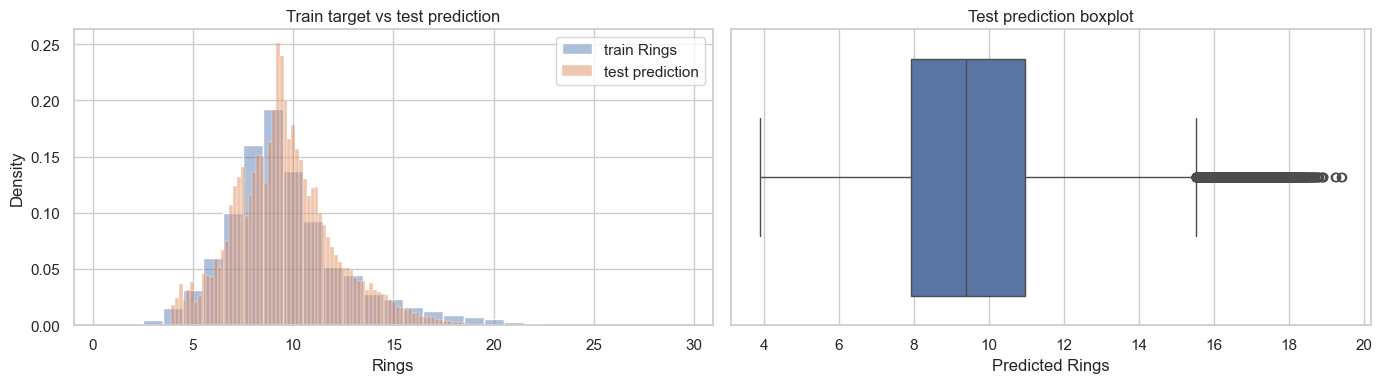

In [5]:
final_model.fit(X, y)
test_pred = np.clip(final_model.predict(X_test), 0, None)

prediction_summary = pd.Series(test_pred, name="predicted_Rings").describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame()

display(prediction_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(y, bins=np.arange(y.min(), y.max() + 2) - 0.5, stat="density", label="train Rings", alpha=0.45, ax=axes[0])
sns.histplot(test_pred, bins=80, stat="density", label="test prediction", alpha=0.45, ax=axes[0])
axes[0].set_title("Train target vs test prediction")
axes[0].set_xlabel("Rings")
axes[0].legend()

sns.boxplot(x=test_pred, ax=axes[1])
axes[1].set_title("Test prediction boxplot")
axes[1].set_xlabel("Predicted Rings")

plt.tight_layout()
plt.show()


## 5. Create and Validate Submission File

`sample_submission.csv`의 `id` 순서를 유지하고 `Rings` 컬럼만 예측값으로 교체합니다.


In [6]:
submission = sample_submission.copy()
submission[TARGET] = test_pred

assert submission.columns.tolist() == [ID_COL, TARGET], "submission must have id,Rings columns."
assert submission[ID_COL].equals(sample_submission[ID_COL]), "submission id order changed."
assert len(submission) == len(test), "submission row count must equal test row count."
assert submission[TARGET].isna().sum() == 0, "submission has missing predictions."
assert np.isfinite(submission[TARGET].to_numpy()).all(), "submission has non-finite predictions."
assert (submission[TARGET] >= 0).all(), "submission has negative predictions."

submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved: {SUBMISSION_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows: {len(submission):,}")
display(submission.head())
display(submission.tail())


Saved: submissions/submission_v2_hgb_log_leaf45_clip.csv
Rows: 60,411


,id,Rings
0,90615,9.687413
1,90616,9.436468
2,90617,9.907020
3,90618,10.486016
4,90619,7.538300


,id,Rings
60406,151021,6.365786
60407,151022,8.998379
60408,151023,12.436996
60409,151024,13.152627
60410,151025,8.429658


## 6. Submission Notes

- 파일명: `submissions/submission_v2_hgb_log_leaf45_clip.csv`
- 모델: `HistGradientBoostingRegressor` with log target and fold-derived modeling configuration
- 피처셋: v2, 39개 피처
- CV 기준: `04_modeling.ipynb`의 best experiment OOF RMSLE `0.149828`
- Kaggle 제출 시 `id,Rings` 두 컬럼만 포함되어야 합니다.
